In [1]:
import sys
from pathlib import Path
import torch

from runner.runners import HybridRunner
from eval.pipeline import SRPipeline
from model.hybrid_model import HybridSRNet

import matplotlib.pyplot as plt

import config

In [2]:
NUM_PATCHES = 64
SCALE_FACTOR = 4
N_SCALE_FACTORS = 3
N_EPOCHS = 20

In [ ]:
zssr_config = {'sigmoid_mode': 'none'}
srresnet_config = {
    'use_batch_norm' : False,
    'final_activation': False
}

INTEGRATION_MODE = 'cascade'
model = HybridSRNet(srresnet_config, zssr_config, integration_mode=INTEGRATION_MODE) 
runner = HybridRunner(model=model)

model.load_srresnet_weights(config.SRRESNET_WEIGHTS_PATH, runner.device)

pipeline = SRPipeline(
    runner=runner,
    dataset_zip_path=config.URBAN100_ZIP,
    datasets_dir=config.DATASET_DIR,
    output_dir=config.HYBRID_OUTPUT_DIR / INTEGRATION_MODE / config.URBAN100_NAME,
    scale_factor=SCALE_FACTOR
)

pipeline.run()

Loaded SRResNet weights from output/srresnet_model_allOFF/srresnet_final.pth
Found 100 LR images. Starting Evaluation Loop...

--- Evaluating: img_092_SRF_4_LR.png ---
Training Hybrid locally on img_092_SRF_4_LR.png...
--- Starting Hybrid Test-Time Training for 50 epochs ---
--- Training ZSSR with s_i=2.0 ---


KeyboardInterrupt: 

In [ ]:
pipeline = SRPipeline(
    runner=runner,
    dataset_zip_path=config.BSD100_ZIP,
    datasets_dir=config.DATASET_DIR,
    output_dir=config.HYBRID_OUTPUT_DIR / INTEGRATION_MODE / config.BSD100_NAME,
    scale_factor=SCALE_FACTOR
)

pipeline.run()

Loaded SRResNet weights from output/srresnet_model_allOFF/srresnet_final.pth


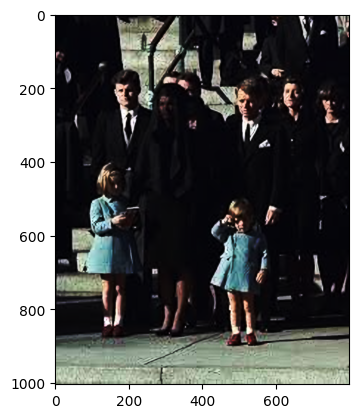

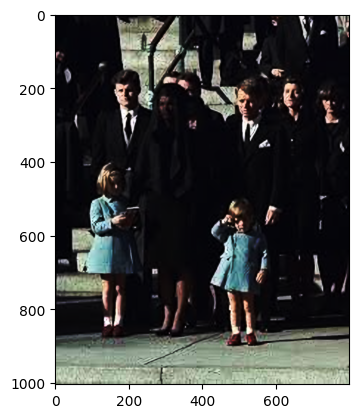

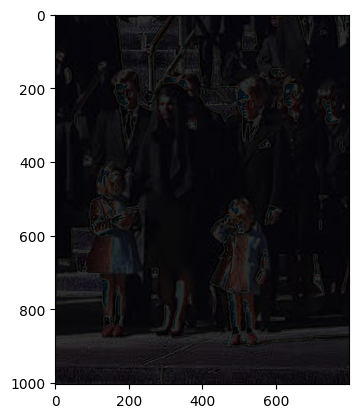

In [10]:
INTEGRATION_MODE = 'fusion_head'
model = HybridSRNet(srresnet_config, zssr_config, integration_mode=INTEGRATION_MODE) 
runner = HybridRunner(model=model)

model.load_srresnet_weights(config.SRRESNET_WEIGHTS_PATH, runner.device)

resnet = model.srresnet
resnet.eval() 

# 1. Load image (plt.imread gives [0.0, 1.0] range)
image_array = plt.imread("./datasets/temp/jfk/jfk.png")
torch_from_image = torch.from_numpy(image_array).permute(2, 0, 1).unsqueeze(0).float()

with torch.no_grad():
    # DO NOT multiply by 2.0 and subtract 1.0
    # Keep it strictly in [0.0, 1.0]

    out_h, out_w = torch_from_image.shape[2] * SCALE_FACTOR, torch_from_image.shape[3] * SCALE_FACTOR
    out_size = torch.Size([out_h, out_w])
    output = model(torch_from_image.to(runner.device), out_size)
    resnet_output = resnet(torch_from_image.to(runner.device))
    
    # If final_activation was OFF, the output is likely already in [0, 1] (or close to it)
    # Clamp it to [0, 1] just for safe plotting, do not do the (out+1)/2 math
    output = output.clamp(0.0, 1.0)
    
    out_img = output.squeeze(0).permute(1, 2, 0).cpu().numpy()
    plt.imshow(out_img)
    plt.show()

    resnet_output = resnet_output.clamp(0.0, 1.0)
    
    resnet_out_img = resnet_output.squeeze(0).permute(1, 2, 0).cpu().numpy()
    plt.imshow(out_img)
    plt.show()

    diff = torch.abs(output - resnet_output).clamp(0.0, 1.0)
    diff_img = diff.squeeze(0).permute(1, 2, 0).cpu().numpy()
    plt.imshow(diff_img)
    plt.show()